In [2]:
import pandas as pd

from sklearn.preprocessing import MultiLabelBinarizer



data = pd.read_csv("resume_dataset_with_salary.csv")


# defining the funtion to remove the spaces and convert the string into the list because mul. works only on list


def clean(col):
  return col.str.lower().str.split(";").apply(lambda x:[i.strip() for i in x])

required_skills = clean(data["skills_required"])
user_skills = clean(data["user_skill"])


mlb = MultiLabelBinarizer()

mlb.fit(required_skills + user_skills)


encoded_required_skills = pd.DataFrame(mlb.transform(required_skills),columns=mlb.classes_)
encoded_user_skills = pd.DataFrame(mlb.transform(user_skills),columns=mlb.classes_)

print(data.head())

   user_id education  experience user_location  \
0        1    Master           0     Port Said   
1        2  Bachelor           6    Alexandria   
2        3  Bachelor           0    Alexandria   
3        4    Master           8         Cairo   
4        5  Bachelor           7     Port Said   

                                          user_skill  \
0                                   SQL;C++;Java;CSS   
1                                    CSS;SQL;PyTorch   
2  Deep Learning;Machine Learning;C++;SQL;PyTorch...   
3  CSS;Java;NLP;TensorFlow;Machine Learning;JavaS...   
4                                       SQL;Java;NLP   

                             skills_required                  job_title  \
0                   NLP;Deep Learning;Python             Data Scientist   
1  Machine Learning;TensorFlow;Deep Learning  Machine Learning Engineer   
2                   Deep Learning;Python;SQL             Data Scientist   
3                        JavaScript;C++;Java         Software 

In [3]:
# finding the skill_gap and matched skills

skill_gap = encoded_required_skills - encoded_user_skills
matched_skills = (encoded_required_skills & encoded_user_skills).sum(axis = 1)


In [4]:
# Now making the Education into the numerical format

data["education"] = data["education"].astype("string").str.strip().str.lower()
edu_map={
    "phd":1,
    "master":2,
    "bachelor":3
}

data["education"] = data["education"].map(edu_map)
data["education"] = data["education"].fillna(0).astype(int)


In [5]:
# Training the data
 # pd.concat -> adding the colums of the skill_gap and dataframe in the left to right

 # pd.DataFrame -> makes the table of the colums given below taking the value from the data set

X = pd.concat([skill_gap,pd.DataFrame({
    "matched_skills":matched_skills,
    "education":data["education"],
    "experience":data["experience"]
})],axis = 1)

# for Y -> use of [ ] it makes the 1D which the model expects (column)
# for X -> use of [[ ]] it makes the 2D which the model expects (rows * columns)


Y = data["selected"]

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train,Y_train)

#finding the accuracy on the training data

y_training = model.predict(X_train)

train_test_accuracy = accuracy_score(Y_train,y_training)
print("Accuracy on the training data is:",train_test_accuracy*100)

# Finding the accuracy on the Testing data
y_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test,y_prediction)
print("Accuracy on the testing data is:", test_data_accuracy*100)



Accuracy on the training data is: 97.75
Accuracy on the testing data is: 94.0


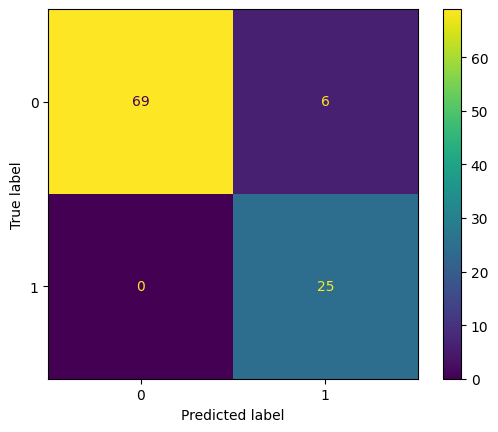

In [7]:
# u can use if u want
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, y_prediction)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [8]:
# saving the file
import pickle
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(mlb, open("mlb.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("features.pkl", "wb")) # it will make sure all the columns are saved in the same order

In [56]:
# Making the Predictive System

model = pickle.load(open("model.pkl","rb"))
mlb = pickle.load(open("mlb.pkl","rb"))
features = pickle.load(open("features.pkl","rb"))

num = int(input("Enter the Number of the Skill: "))
user_skills = []

for i in range(num):
  skill = input(f"Enter the {i+1} skill: ").strip().lower()
  user_skills.append(skill)
experience = int(input("Enter the Experience: "))
education = input("Enter education (Bachelor/Master/PhD): ").strip().lower()

required_skill = ["deep learning", "python", "sql"]


# using the [] here the items are ,treated as one
# if no bracket is used in the transform ,treated as multiple items

user_encoded = pd.DataFrame(
    mlb.transform([user_skills]), columns=mlb.classes_
)

required_encoded = pd.DataFrame(
    mlb.transform([required_skill]), columns=mlb.classes_
)

skill_gap = user_encoded - required_encoded
matched_skills = (user_encoded & required_encoded).sum(axis=1)

edu_map = {"bachelor":1 ,"master":2,"phd":3}

# get works on the one input and the map works on the entire column
updated_value = edu_map.get(education,0)

input_df = pd.concat([skill_gap,pd.DataFrame({
        "matched_skills": matched_skills,
        "education": [updated_value],
        "experience": [experience]
    })
], axis=1)

# Exact same columns as training (features)
# Same column order
# automatic fill with the 0 value

input_df = input_df.reindex(columns=features, fill_value=0)
prediction = model.predict(input_df)[0]

# getting the percentage of selection

'''
someting like this -> predict_probo
[
  [0.80, 0.20]

  0.80 -> 0  not selected
  0.20 -> 1  selected
]

'''
prob = model.predict_proba(input_df)[0][1]

print("Probability of getting selected:",round(prob *100 ,2),'%')

if prediction == 1:
  print("Resume is Selected")
else:
  print("Resume not Selected")

Enter the Number of the Skill: 3
Enter the 1 skill: deep learning
Enter the 2 skill: python
Enter the 3 skill: sql
Enter the Experience: 4
Enter education (Bachelor/Master/PhD): phd
Probability of getting selected: 99.91 %
